In [61]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder, KBinsDiscretizer
from sklearn.model_selection import StratifiedKFold
import numpy as np
from matplotlib import pyplot as plt
from matplotlib.figure import Figure
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.naive_bayes import GaussianNB, BernoulliNB

In [62]:
df = pd.read_csv("../data/train_clear.csv")

In [63]:
target = "Liver_Disease_Type"
X = df.drop(columns=[target])
y = df[target]

In [64]:
cat_cols = X.select_dtypes(include="string").columns

numeric_cols = X.select_dtypes(include="number").columns
num_cols = [col for col in numeric_cols if len(df[col].unique()) > 2]

In [65]:
X_encoded = X.copy()

In [66]:
encoder = OrdinalEncoder(handle_unknown="use_encoded_value", unknown_value=-1, dtype=np.int64)
X_encoded[cat_cols] = encoder.fit_transform(X_encoded[cat_cols].to_numpy())

In [67]:
le = LabelEncoder()
y_encoded = np.array(le.fit_transform(y))

In [68]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = []

In [69]:
def train_model(model, X, y):
    all_y_true = []
    all_y_pred = []
    for fold, (train_index, val_index) in enumerate(skf.split(X, y)):
        X_train, X_val = X.iloc[train_index], X.iloc[val_index]
        y_train, y_val = y[train_index], y[val_index]
        
        model.fit(X_train.to_numpy(), y_train)

        y_pred = model.predict(X_val.to_numpy())
        
        score = model.score(X_val.to_numpy(), y_val)
        cv_scores.append(score)

        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)

    scores = np.array(cv_scores)
    print(f"Точность {model}: {scores.mean():0.3f} ± {scores.std():0.3f}")

    fig, ax = plt.subplots(figsize=(8, 6))
    disp_raw = ConfusionMatrixDisplay.from_predictions(
        all_y_true, 
        all_y_pred, 
        display_labels=le.classes_,
        ax=ax,
        normalize="true"
    )
    plt.xticks(rotation=45, ha='right')

Точность GaussianNB(): 0.781 ± 0.003


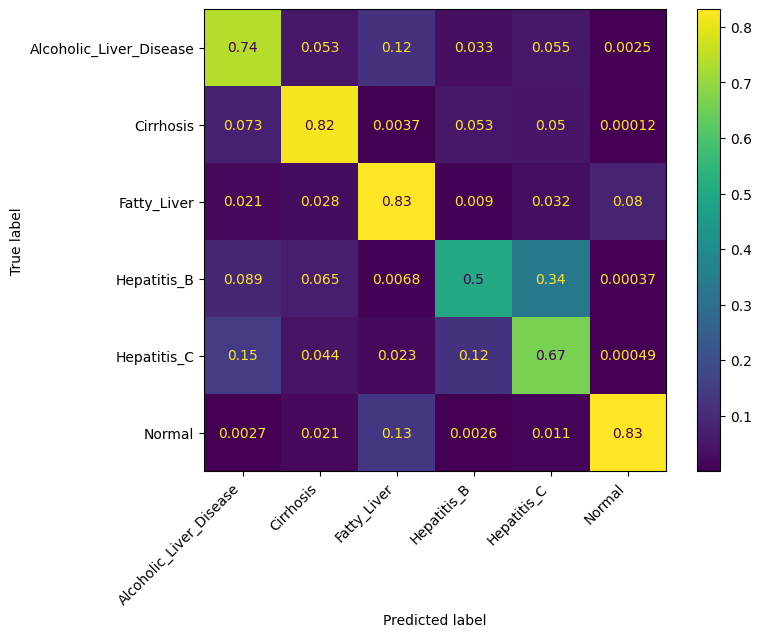

In [70]:
gaussian_nb = GaussianNB()
train_model(gaussian_nb, X_encoded, y_encoded)

Точность BernoulliNB(): 0.698 ± 0.084


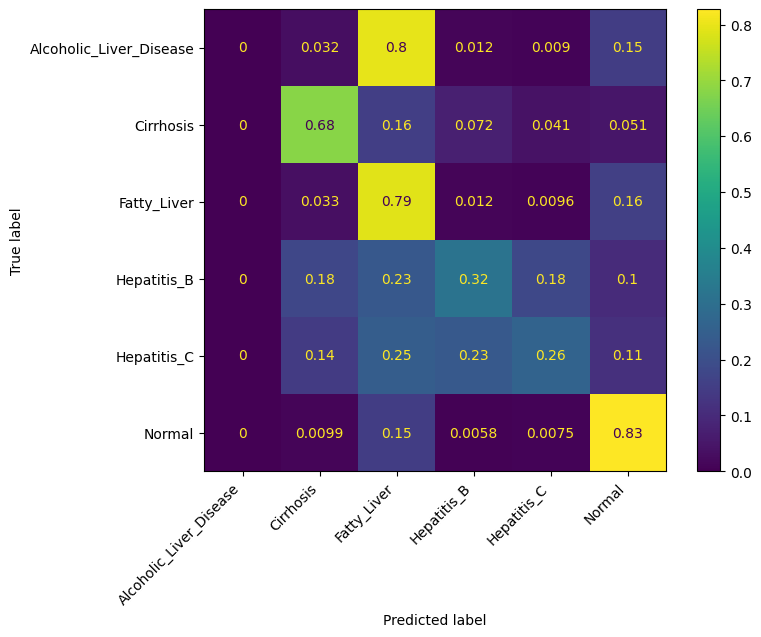

In [ ]:
gaussian_nb = BernoulliNB()
train_model(gaussian_nb, X_encoded, y_encoded)

# Так как бернулли работает с бинарными признаками он теряет информацию о величине непрерывных признаков
# что критично в медицинских данных